## Projectile Motion in 2D

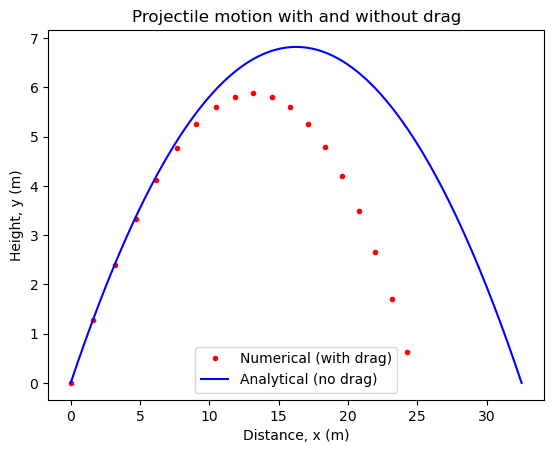

The distance to impact is 24.867720 m
The maximum height is 5.877568 m
The time of flight is 2.184298 s
The velocity at the impact point (vx, vy) = (9.469058, -10.068842) m/s
Impact velocity is therefore 13.821890 m/s, -46.758343 degrees from the horizontal
Distance that drag reduces the range is 7.658040


In [1]:
from scipy import integrate
import matplotlib.pyplot as plt
import numpy as np

b = 0.006  #atmospheric friction in kg/m
g = 9.81  # gravitational acceleration in m/s**2
m = 0.45  # mass in kg
v0 = 18  # initial velocity in m/s
theta = 40  # initial angle above the horizontal in degrees


def dydt(t, y_arr):
    x = y_arr[0]  # x position
    y = y_arr[1]  # y position
    vx = y_arr[2]  # velocity in x direction
    vy = y_arr[3]  # velocity in y direction
    v = np.sqrt(vx**2 + vy**2)  # magnitude of velocity vector
    return np.array([vx, vy, -(b / m) * v * vx, (-g - (b / m) * v * vy)])  # This is [dx/dt, dy/dt, dvx/dt, dvy/dt]


t0 = 0  # initial time
tmax = (2 / g) * v0 * np.sin(np.radians(theta)) # final time (time unitl impact with no drag, we know this is > time until impact with drag)
steps = 500  # time steps

# 1d time array
t_arr = np.linspace(t0, tmax, steps + 1)

# initial conditions for x, y, dx/dt, dy/dt
y0_arr = np.array(
    [0, 0, v0 * np.cos(np.radians(theta)), v0 * np.sin(np.radians(theta))])


# event marker for impact
def impact(t, y):
    return y[1]


impact.terminal = True
impact.direction = -1


#Analytical solution
def xt(t):
    return v0 * t * np.cos(np.radians(theta))


def yt(t):
    return v0 * t * np.sin(np.radians(theta)) - 0.5 * g * t**2


# Solving the differential equation
sol = integrate.solve_ivp(dydt, (t_arr[0], t_arr[-1]),
                          y0_arr,
                          t_eval=t_arr,
                          events=impact,
                          method='LSODA')

t_sol = sol['t']
x_sol = sol['y'][0]
y_sol = sol['y'][1]
vx_sol = sol['y'][2]
vy_sol = sol['y'][3]

plt.plot(x_sol[::25], y_sol[::25], 'r.', label='Numerical (with drag)')
plt.plot(xt(t_arr), yt(t_arr), 'b-', label='Analytical (no drag)')
plt.title('Projectile motion with and without drag')
plt.xlabel('Distance, x (m)')
plt.ylabel('Height, y (m)')
plt.legend()
plt.show()

print("The distance to impact is %f m" % (np.max(x_sol)))
print("The maximum height is %f m" % (np.max(y_sol)))
print("The time of flight is %f s" % (np.max(t_sol)))
print("The velocity at the impact point (vx, vy) = (%f, %f) m/s" %
      (vx_sol[-1], vy_sol[-1]))
print("Impact velocity is therefore %f m/s, %f degrees from the horizontal" %
      (np.sqrt(vx_sol[-1]**2 + vy_sol[-1]**2),
       (np.arctan(vy_sol[-1] / vx_sol[-1])) / (2 * np.pi) * 360))
print("Distance that drag reduces the range is %f" %
      (xt(t_arr)[-1] - x_sol[-1]))